# Keypoints demo - load and visualize

This notebook demonstrates how to load and visualize keypoints data saved using Facemap. 

#### Import packages

In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
# sys.path.insert(0,  '/home/stringlab/Facemap/facemap')
from facemap import utils
from facemap.pose import refine_pose

### Load data
12.19

In [2]:
keypoints_filepath = '20251219104504 Cam 1 20251219 104528_FacemapPose.h5' # Set your path here

In [3]:
keypoints_data = utils.load_keypoints(refine_pose.BODYPARTS, keypoints_filepath)
print(keypoints_data.shape)
# Keypoints data is a 3D array of shape (3, num_bodyparts, num_frames)
# The first dimension is (x, y, likelihood)

(3, 15, 125992)


In [8]:
keypoints_data

array([[[279.04343   , 279.4873    , 279.5103    , ..., 279.4614    ,
         279.63232   , 279.48453   ],
        [255.42966   , 255.16852   , 255.12244   , ..., 255.94614   ,
         256.06528   , 256.04456   ],
        [232.79184   , 232.93661   , 232.8172    , ..., 232.60257   ,
         232.7128    , 232.57425   ],
        ...,
        [163.92494   , 163.63103   , 164.19102   , ..., 163.74037   ,
         163.86406   , 163.64362   ],
        [176.63805   , 177.22058   , 177.6784    , ..., 176.328     ,
         176.30746   , 176.36305   ],
        [167.17046   , 167.46518   , 167.97263   , ..., 168.565     ,
         168.66042   , 168.69324   ]],

       [[177.03876   , 177.1152    , 177.18214   , ..., 175.05927   ,
         175.12338   , 175.01817   ],
        [188.11067   , 188.31244   , 188.3864    , ..., 185.78337   ,
         185.85265   , 185.82285   ],
        [170.61581   , 170.59627   , 170.68822   , ..., 168.92455   ,
         168.95059   , 168.83228   ],
        ...,


### Visualize data

In [4]:
pose_x_coord = keypoints_data[0, :, :]
pose_y_coord = keypoints_data[1, :, :]
pose_likelihood = keypoints_data[2, :, :]
colors = cm.get_cmap("jet")(np.linspace(0, 1.0, len(refine_pose.BODYPARTS)))

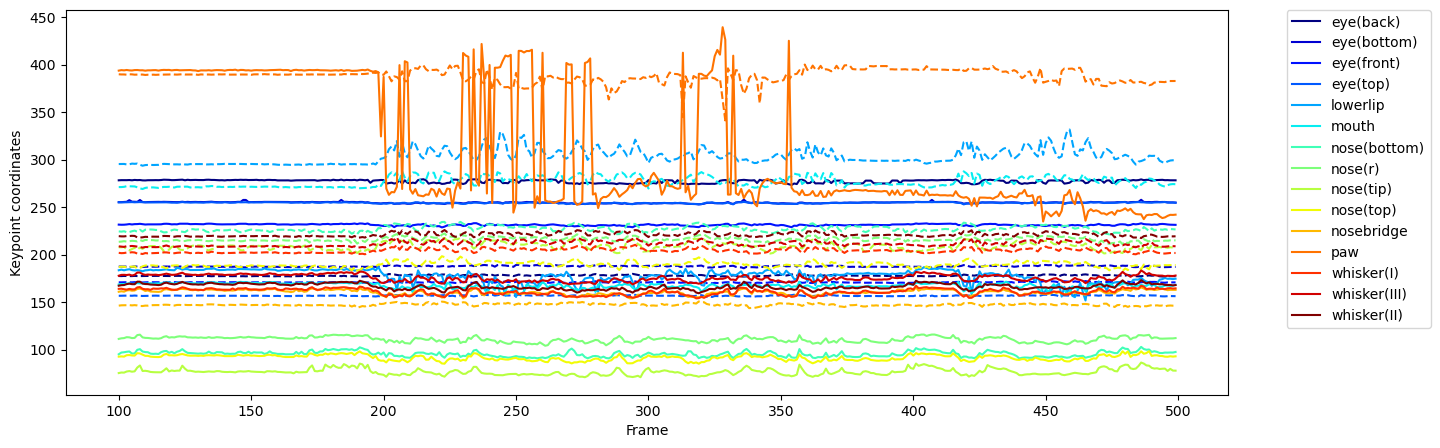

In [5]:
# Plot keypoints for a subset of frames
start_frame = 100
end_frame = 500

plt.figure(figsize=(15, 5), dpi=100)
for i, bodypart in enumerate(refine_pose.BODYPARTS):
    plt.plot(np.arange(start_frame, end_frame), pose_x_coord[i, start_frame:end_frame], '-', c=colors[i], label=bodypart)
    plt.plot(np.arange(start_frame, end_frame), pose_y_coord[i, start_frame:end_frame], '--', c=colors[i])
plt.xlabel('Frame')
plt.ylabel('Keypoint coordinates')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.show()

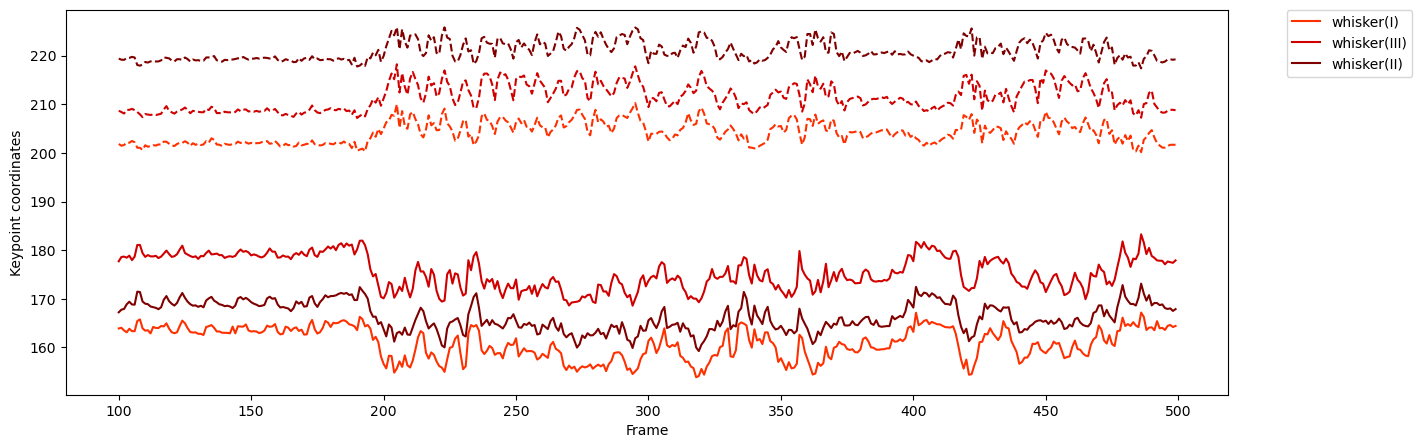

In [6]:
# Plot a subset of keypoints for a subset of frames
subset_bodyparts = ["whisker(I)",  "whisker(II)", "whisker(III)"]
start_frame = 100
end_frame = 500

plt.figure(figsize=(15, 5), dpi=100)
for i, bodypart in enumerate(refine_pose.BODYPARTS):
    if bodypart in subset_bodyparts:
        plt.plot(np.arange(start_frame, end_frame), pose_x_coord[i, start_frame:end_frame], '-', c=colors[i], 
                 label=bodypart)
        plt.plot(np.arange(start_frame, end_frame), pose_y_coord[i, start_frame:end_frame], '--', c=colors[i])
plt.xlabel('Frame')
plt.ylabel('Keypoint coordinates')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.show()

### Filter keypoints data by confidence 

Apply median filter to the keypoints data to remove outliers.

c:\ProgramData\anaconda3\envs\facemap\lib\site-packages\numpy\lib\nanfunctions.py:1217: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a, func=_nanmedian, keepdims=keepdims,


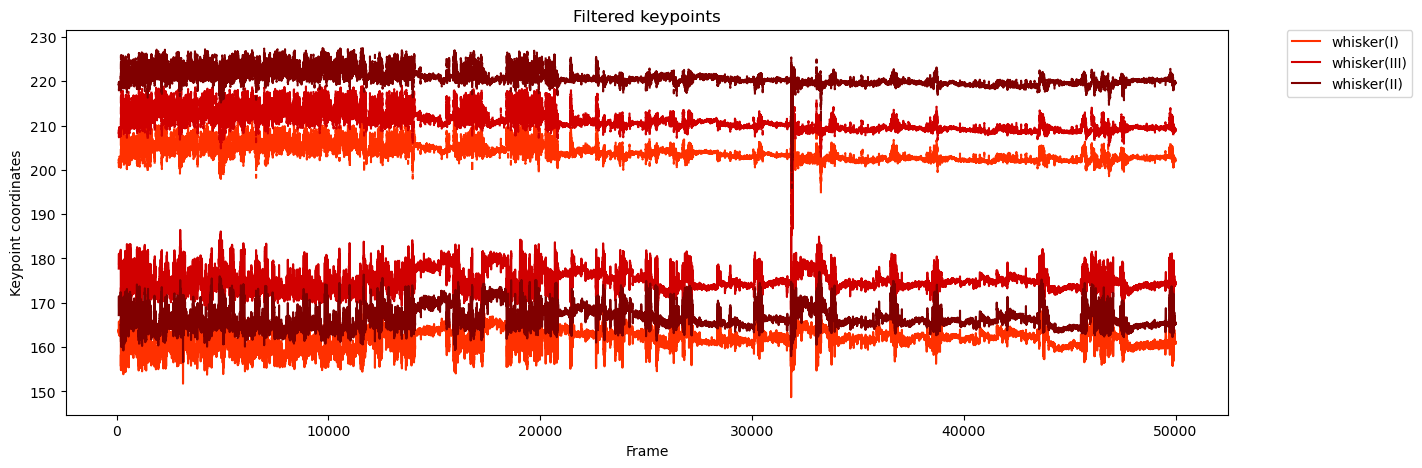

In [7]:
# Use the following function to filter outliers in the keypoints data (see docstring for details)
"""
utils.filter_outliers(x, y, filter_window=15, baseline_window=50, max_spike=25, max_diff=25)
x: x coordinates of keypoints
y: y coordinates of keypoints
filter_window: window size for median filter (default: 15)
baseline_window: window size for baseline estimation (default: 50)
max_spike: maximum spike size (default: 25)
max_diff: maximum difference between baseline and filtered signal (default: 25)
"""
start_frame = 100
end_frame = 50000

plt.figure(figsize=(15, 5), dpi=100)
for i, bodypart in enumerate(refine_pose.BODYPARTS):
    if bodypart in subset_bodyparts:
        x, y = utils.filter_outliers(pose_x_coord[i], pose_y_coord[i])
        plt.plot(np.arange(start_frame, end_frame), x[start_frame:end_frame], '-', c=colors[i], label=bodypart)
        plt.plot(np.arange(start_frame, end_frame), y[start_frame:end_frame], '--', c=colors[i])
plt.xlabel('Frame')
plt.ylabel('Keypoint coordinates')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.title('Filtered keypoints')
plt.show()

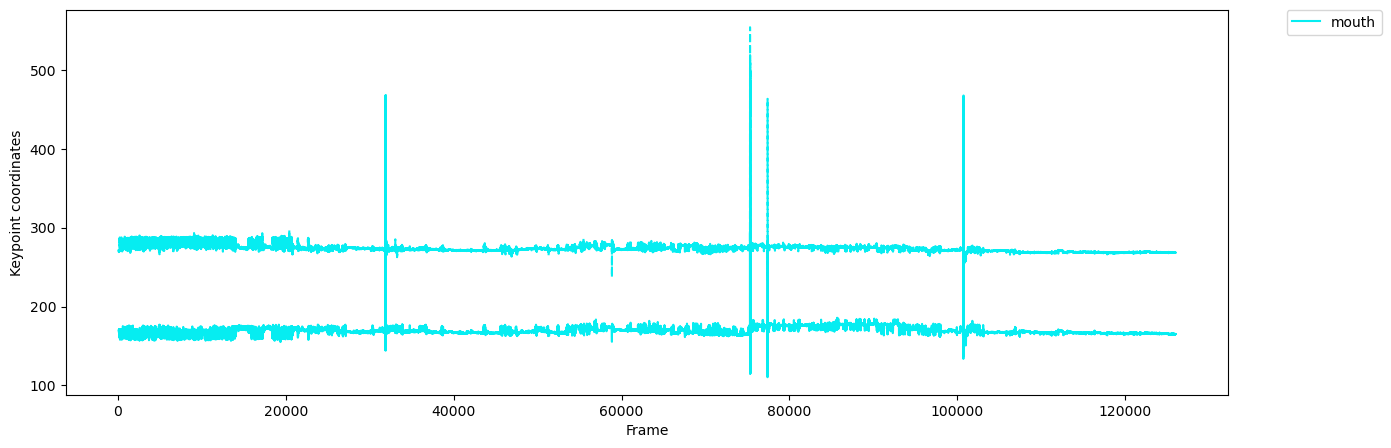

In [11]:
subset_bodyparts = ["mouth"]

start_frame = 100
end_frame = 125992

plt.figure(figsize=(15, 5), dpi=100)
for i, bodypart in enumerate(refine_pose.BODYPARTS):
    if bodypart in subset_bodyparts:
        plt.plot(np.arange(start_frame, end_frame), pose_x_coord[i, start_frame:end_frame], '-', c=colors[i], 
                 label=bodypart)
        plt.plot(np.arange(start_frame, end_frame), pose_y_coord[i, start_frame:end_frame], '--', c=colors[i])
plt.xlabel('Frame')
plt.ylabel('Keypoint coordinates')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.show()